In [1]:
# Import libraries for data handling, modeling, and visualization
from pathlib import Path
import re
import json
import time
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Disable XLA JIT compilation to avoid occasional very slow compile steps
tf.config.optimizer.set_jit(False)

# Reduce TensorFlow log noise
tf.get_logger().setLevel("ERROR")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

# Plotting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", 120)

print("TensorFlow version:", tf.__version__)

2026-06-21 07:56:30.453326: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782028590.685450      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782028590.749690      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782028591.336605      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782028591.336648      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782028591.336651      24 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [ ]:
# Kaggle dataset location
DATA_DIR = Path("adjust data path!")

OUTPUT_DIR = Path("/kaggle/working/notebook_04_single_signal")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FOLD_RESULTS_PATH = OUTPUT_DIR / "single_signal_fold_results_incremental.csv"
WINDOW_PREDICTIONS_PATH = OUTPUT_DIR / "single_signal_window_predictions_incremental.csv"
SEGMENT_PREDICTIONS_PATH = OUTPUT_DIR / "single_signal_segment_predictions_incremental.csv"

TIME_COLUMN = "Time (s)"
TARGET_COLUMN = "Energy expenditures (W/kg)"
ACTIVITY_COLUMN = "Activity Code"
LEAKAGE_COLUMN = "VO2"
SUBJECT_COLUMN = "Subject"
SEGMENT_COLUMN = "Segment ID"

WINDOW_SIZE = 30
STEP_SIZE = 10
MAX_TIME_GAP = 1.5

SUBJECT_WEIGHTS = {
    1: 63.49,
    2: 63.49,
    3: 71.20,
    4: 68.03,
    5: 68.03,
    6: 68.03,
    7: 95.24,
    8: 65.76,
    9: 68.93,
    10: 58.05,
}

WATT_TO_KCAL_PER_MINUTE = 60 / 4184

INPUT_SIGNALS = [
    "Waist Acceleration",
    "Chest Acceleration",
    "Left Ankle Acceleration",
    "right Ankle Acceleration",
    "left wrist Acceleration",
    "right wrist Acceleration",
    "EMG_magnitude_left",
    "EMG_magnitude_right",
    "left wrist electrodermal",
    "right wrist electrodermal",
    "left wrist Temperature",
    "right wrist Temperature",
    "Breath Frequency",
    "Minute Ventilation",
    "SpO2",
    "Heart Rate",
]

FINAL_CNN_CONFIG = {
    "name": "tiny_residual_tcn",
    "architecture": "tiny_residual_tcn",
    "filters": 32,
    "kernel_size": 3,
    "dense_units": 32,
    "dropout": 0.1,
    "learning_rate": 0.001,
    "batch_size": 64,
    "max_epochs": 100,
    "early_stopping_patience": 12,
}

print("Number of input signals:", len(INPUT_SIGNALS))
print(json.dumps(FINAL_CNN_CONFIG, indent=2))

In [3]:
def extract_subject_id(file_path):
    """Extract the numeric subject ID from a filename."""
    match = re.search(r"\((\d+)\)", file_path.name)

    if match is None:
        raise ValueError(f"Could not extract subject ID from {file_path.name}")

    return int(match.group(1))


def load_subject_data(data_dir):
    """Load all subject CSV files and preserve original row order."""
    csv_files = sorted(
        data_dir.rglob("Subject*.csv"),
        key=extract_subject_id,
    )

    if len(csv_files) != 10:
        raise ValueError(f"Expected 10 subject files, found {len(csv_files)}.")

    frames = []

    for file_path in csv_files:
        subject_frame = pd.read_csv(file_path)

        # Remove accidental whitespace from column names
        subject_frame.columns = subject_frame.columns.str.strip()

        subject_frame[SUBJECT_COLUMN] = extract_subject_id(file_path)
        subject_frame["Subject Row"] = np.arange(len(subject_frame))

        frames.append(subject_frame)

    return pd.concat(frames, ignore_index=True)


data = load_subject_data(DATA_DIR)
data["Weight_kg"] = data[SUBJECT_COLUMN].map(SUBJECT_WEIGHTS)

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (71248, 23)


,Time (s),Waist Acceleration,Chest Acceleration,Left Ankle Acceleration,right Ankle Acceleration,EMG_magnitude_left,EMG_magnitude_right,left wrist Acceleration,right wrist Acceleration,left wrist electrodermal,right wrist electrodermal,left wrist Temperature,right wrist Temperature,VO2,Breath Frequency,Minute Ventilation,SpO2,Heart Rate,Energy expenditures (W/kg),Activity Code,Subject,Subject Row,Weight_kg
0,360.0,9.881434,9.907993,10.376973,10.556383,0.236835,0.218084,9.770370,9.770370,0.154151,0.123130,32.572006,33.118418,6.595555,18.0,12.0,100.0,79.0,1.889876,1,1,0,63.49
1,361.0,9.893783,9.935137,10.825692,10.890038,0.257191,0.233938,9.787784,9.787784,0.154170,0.123169,32.571455,33.117456,6.595555,18.0,12.0,100.0,79.0,1.889876,1,1,1,63.49
2,362.0,9.906331,9.967683,11.345032,11.291269,0.275078,0.244958,9.793522,9.793522,0.154184,0.123205,32.570829,33.116544,10.765078,21.0,19.0,100.0,87.0,1.889876,1,1,2,63.49
3,363.0,9.917098,9.999778,11.830694,11.735178,0.288368,0.251887,9.787376,9.787376,0.154201,0.123245,32.570220,33.115703,10.765078,21.0,19.0,100.0,87.0,1.889876,1,1,3,63.49
4,364.0,9.923104,10.024502,12.166507,12.132302,0.296400,0.255063,9.774731,9.774731,0.154212,0.123285,32.569646,33.114890,10.765078,21.0,19.0,100.0,87.0,1.889876,1,1,4,63.49


In [4]:
def add_segment_ids(frame):
    """Assign a unique ID to each continuous activity trial."""
    frame = frame.copy()

    frame = frame.sort_values(
        [SUBJECT_COLUMN, "Subject Row"]
    ).reset_index(drop=True)

    time_difference = frame.groupby(SUBJECT_COLUMN)[TIME_COLUMN].diff()

    subject_changed = frame[SUBJECT_COLUMN].ne(
        frame[SUBJECT_COLUMN].shift()
    )

    activity_changed = frame[ACTIVITY_COLUMN].ne(
        frame[ACTIVITY_COLUMN].shift()
    )

    time_moved_backwards = time_difference.le(0)
    time_gap_too_large = time_difference.gt(MAX_TIME_GAP)

    new_segment = (
        subject_changed
        | activity_changed
        | time_moved_backwards
        | time_gap_too_large
    )

    frame[SEGMENT_COLUMN] = new_segment.cumsum().astype(int)

    return frame


data = add_segment_ids(data)

print("Detected segments:", data[SEGMENT_COLUMN].nunique())

Detected segments: 198


In [5]:
def create_all_signal_windows(
    frame,
    input_signals,
    window_size,
    step_size,
):
    """Create raw windows for all allowed input signals."""
    windows = []
    metadata_rows = []

    for segment_id, segment in frame.groupby(SEGMENT_COLUMN, sort=True):
        segment = segment.reset_index(drop=True)

        # Each segment must correspond to one subject, one activity, one target
        assert segment[SUBJECT_COLUMN].nunique() == 1
        assert segment[ACTIVITY_COLUMN].nunique() == 1
        assert segment[TARGET_COLUMN].nunique() == 1

        subject_id = int(segment[SUBJECT_COLUMN].iloc[0])
        activity_code = int(segment[ACTIVITY_COLUMN].iloc[0])
        target_w_kg = float(segment[TARGET_COLUMN].iloc[0])
        weight_kg = float(segment["Weight_kg"].iloc[0])

        target_kcal_min = (
            target_w_kg
            * weight_kg
            * WATT_TO_KCAL_PER_MINUTE
        )

        signal_values = segment[input_signals].to_numpy(dtype=np.float32)

        for start_index in range(
            0,
            len(segment) - window_size + 1,
            step_size,
        ):
            end_index = start_index + window_size

            windows.append(signal_values[start_index:end_index])

            metadata_rows.append({
                "Window ID": len(windows) - 1,
                SEGMENT_COLUMN: int(segment_id),
                SUBJECT_COLUMN: subject_id,
                ACTIVITY_COLUMN: activity_code,
                "Start Index": start_index,
                "End Index": end_index,
                "Target_W_kg": target_w_kg,
                "Weight_kg": weight_kg,
                "Target_kcal_min": target_kcal_min,
            })

    X = np.stack(windows).astype(np.float32)
    metadata = pd.DataFrame(metadata_rows)

    return X, metadata


X_all_raw, metadata = create_all_signal_windows(
    data,
    INPUT_SIGNALS,
    WINDOW_SIZE,
    STEP_SIZE,
)

print("X_all_raw shape:", X_all_raw.shape)
print("Metadata shape:", metadata.shape)
display(metadata.head())

X_all_raw shape: (6724, 30, 16)
Metadata shape: (6724, 9)


,Window ID,Segment ID,Subject,Activity Code,Start Index,End Index,Target_W_kg,Weight_kg,Target_kcal_min
0,0,1,1,1,0,30,1.889876,63.49,1.720672
1,1,1,1,1,10,40,1.889876,63.49,1.720672
2,2,1,1,1,20,50,1.889876,63.49,1.720672
3,3,1,1,1,30,60,1.889876,63.49,1.720672
4,4,1,1,1,40,70,1.889876,63.49,1.720672


In [6]:
assert X_all_raw.shape[0] == len(metadata)
assert X_all_raw.shape[1] == WINDOW_SIZE
assert X_all_raw.shape[2] == len(INPUT_SIGNALS)
assert metadata[SUBJECT_COLUMN].nunique() == 10
assert metadata[SEGMENT_COLUMN].nunique() == 198

missing_per_signal = pd.Series(
    np.isnan(X_all_raw).sum(axis=(0, 1)),
    index=INPUT_SIGNALS,
    name="Missing Values",
)

display(missing_per_signal[missing_per_signal > 0])

print("Window validation passed.")

right wrist Acceleration     11220
right wrist electrodermal    11220
right wrist Temperature      11220
Name: Missing Values, dtype: int64

Window validation passed.


In [7]:
def create_loso_splits(subject_ids):
    """Create deterministic LOSO splits with one validation subject."""
    subject_ids = sorted(subject_ids)
    splits = []

    for test_position, test_subject in enumerate(subject_ids):
        validation_subject = subject_ids[
            (test_position + 1) % len(subject_ids)
        ]

        train_subjects = [
            subject
            for subject in subject_ids
            if subject not in [test_subject, validation_subject]
        ]

        splits.append({
            "Fold": test_position + 1,
            "Train Subjects": train_subjects,
            "Validation Subject": validation_subject,
            "Test Subject": test_subject,
        })

    return splits


def get_split_indices(metadata, split):
    """Return train, validation, and test window indices."""
    train_mask = metadata[SUBJECT_COLUMN].isin(
        split["Train Subjects"]
    )

    validation_mask = metadata[SUBJECT_COLUMN].eq(
        split["Validation Subject"]
    )

    test_mask = metadata[SUBJECT_COLUMN].eq(
        split["Test Subject"]
    )

    return {
        "train": np.flatnonzero(train_mask),
        "validation": np.flatnonzero(validation_mask),
        "test": np.flatnonzero(test_mask),
    }


def get_final_loso_indices(metadata, split):
    """Return final train and test indices using all non-test subjects."""
    test_mask = metadata[SUBJECT_COLUMN].eq(
        split["Test Subject"]
    )

    train_mask = ~test_mask

    return {
        "train": np.flatnonzero(train_mask),
        "test": np.flatnonzero(test_mask),
    }


loso_splits = create_loso_splits(
    metadata[SUBJECT_COLUMN].unique()
)

display(pd.DataFrame(loso_splits))

,Fold,Train Subjects,Validation Subject,Test Subject
0,1,"[3, 4, 5, 6, 7, 8, 9, 10]",2,1
1,2,"[1, 4, 5, 6, 7, 8, 9, 10]",3,2
2,3,"[1, 2, 5, 6, 7, 8, 9, 10]",4,3
3,4,"[1, 2, 3, 6, 7, 8, 9, 10]",5,4
4,5,"[1, 2, 3, 4, 7, 8, 9, 10]",6,5
5,6,"[1, 2, 3, 4, 5, 8, 9, 10]",7,6
6,7,"[1, 2, 3, 4, 5, 6, 9, 10]",8,7
7,8,"[1, 2, 3, 4, 5, 6, 7, 10]",9,8
8,9,"[1, 2, 3, 4, 5, 6, 7, 8]",10,9
9,10,"[2, 3, 4, 5, 6, 7, 8, 9]",1,10


In [8]:
def fit_signal_normalizer(X_train):
    """Fit per-signal normalization using training data only."""
    signal_mean = np.nanmean(X_train, axis=(0, 1))
    signal_std = np.nanstd(X_train, axis=(0, 1))

    signal_std = np.where(signal_std < 1e-8, 1.0, signal_std)

    return signal_mean.astype(np.float32), signal_std.astype(np.float32)


def transform_signal_windows(X, signal_mean, signal_std):
    """Normalize signal windows and replace missing values with neutral zeros."""
    X_scaled = (X - signal_mean) / signal_std

    X_scaled = np.nan_to_num(
        X_scaled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    return X_scaled.astype(np.float32)


def fit_target_normalizer(y_train):
    """Fit target normalization using training targets only."""
    target_mean = float(np.mean(y_train))
    target_std = float(np.std(y_train))

    if target_std < 1e-8:
        target_std = 1.0

    return target_mean, target_std


def transform_targets(y, target_mean, target_std):
    """Normalize target values."""
    return ((y - target_mean) / target_std).astype(np.float32)


def inverse_transform_targets(y_scaled, target_mean, target_std):
    """Convert normalized predictions back to W/kg."""
    return y_scaled * target_std + target_mean

In [9]:
def calculate_regression_metrics(y_true, y_pred):
    """Calculate RMSE, MAE, and R-squared."""
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }


def create_prediction_frame(metadata_subset, predictions_w_kg):
    """Combine metadata, targets, and predictions."""
    prediction_frame = metadata_subset.copy().reset_index(drop=True)

    prediction_frame["Prediction_W_kg"] = predictions_w_kg

    prediction_frame["Prediction_kcal_min"] = (
        prediction_frame["Prediction_W_kg"]
        * prediction_frame["Weight_kg"]
        * WATT_TO_KCAL_PER_MINUTE
    )

    return prediction_frame


def aggregate_predictions_by_segment(prediction_frame):
    """Average window predictions to one prediction per trial segment."""
    return (
        prediction_frame.groupby(SEGMENT_COLUMN)
        .agg(
            Subject=(SUBJECT_COLUMN, "first"),
            Activity_Code=(ACTIVITY_COLUMN, "first"),
            Target_W_kg=("Target_W_kg", "first"),
            Prediction_W_kg=("Prediction_W_kg", "mean"),
            Target_kcal_min=("Target_kcal_min", "first"),
            Prediction_kcal_min=("Prediction_kcal_min", "mean"),
            Number_of_Windows=("Window ID", "size"),
        )
        .reset_index()
    )


def evaluate_predictions(metadata_subset, predictions_w_kg):
    """Evaluate predictions on window and segment level."""
    prediction_frame = create_prediction_frame(
        metadata_subset,
        predictions_w_kg,
    )

    segment_frame = aggregate_predictions_by_segment(prediction_frame)

    results = {}

    for level, frame in [
        ("Window", prediction_frame),
        ("Segment", segment_frame),
    ]:
        metrics_w_kg = calculate_regression_metrics(
            frame["Target_W_kg"],
            frame["Prediction_W_kg"],
        )

        metrics_kcal_min = calculate_regression_metrics(
            frame["Target_kcal_min"],
            frame["Prediction_kcal_min"],
        )

        for metric_name, value in metrics_w_kg.items():
            results[f"{level}_{metric_name}_W_kg"] = value

        for metric_name, value in metrics_kcal_min.items():
            results[f"{level}_{metric_name}_kcal_min"] = value

    return results, prediction_frame, segment_frame

In [10]:
def make_tf_dataset(X, y, batch_size, shuffle):
    """Create a TensorFlow dataset."""
    dataset = tf.data.Dataset.from_tensor_slices((X, y))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(X),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [11]:
def residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout):
    """Create one compact residual temporal convolution block."""
    shortcut = x

    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
    )(x)
    x = layers.BatchNormalization()(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same",
        )(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    return x


def build_tiny_residual_tcn(config, input_channels=1):
    """Build the final Tiny Residual TCN model."""
    inputs = keras.Input(
        shape=(WINDOW_SIZE, input_channels),
        name="signal_window",
    )

    x = layers.Conv1D(
        filters=config["filters"],
        kernel_size=1,
        padding="same",
        name="input_projection",
    )(inputs)

    x = residual_tcn_block(
        x,
        filters=config["filters"],
        kernel_size=config["kernel_size"],
        dilation_rate=1,
        dropout=config["dropout"],
    )

    x = residual_tcn_block(
        x,
        filters=config["filters"],
        kernel_size=config["kernel_size"],
        dilation_rate=2,
        dropout=config["dropout"],
    )

    x = residual_tcn_block(
        x,
        filters=config["filters"],
        kernel_size=config["kernel_size"],
        dilation_rate=4,
        dropout=config["dropout"],
    )

    x = layers.GlobalAveragePooling1D(
        name="global_average_pooling",
    )(x)

    x = layers.Dense(
        config["dense_units"],
        activation="relu",
        name="dense",
    )(x)

    outputs = layers.Dense(
        1,
        activation="linear",
        name="ee_prediction_scaled",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=config["name"],
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=config["learning_rate"],
    )

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae"),
        ],
    )

    return model

In [12]:
def train_model(
    config,
    X_train,
    y_train,
    X_validation=None,
    y_validation=None,
    epochs=None,
    use_early_stopping=True,
    verbose=0,
):
    """Train one Tiny Residual TCN model."""
    tf.keras.backend.clear_session()

    model = build_tiny_residual_tcn(
        config,
        input_channels=X_train.shape[-1],
    )

    train_dataset = make_tf_dataset(
        X_train,
        y_train,
        batch_size=config["batch_size"],
        shuffle=True,
    )

    callbacks = []

    validation_data = None

    if X_validation is not None and y_validation is not None:
        validation_dataset = make_tf_dataset(
            X_validation,
            y_validation,
            batch_size=config["batch_size"],
            shuffle=False,
        )

        validation_data = validation_dataset

        if use_early_stopping:
            callbacks.append(
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=config["early_stopping_patience"],
                    restore_best_weights=True,
                )
            )

    if epochs is None:
        epochs = config["max_epochs"]

    history = model.fit(
        train_dataset,
        validation_data=validation_data,
        epochs=epochs,
        callbacks=callbacks,
        verbose=verbose,
    )

    return model, history

In [13]:
def load_existing_results():
    """Load already saved fold results and predictions if available."""
    if FOLD_RESULTS_PATH.exists():
        existing_fold_results = pd.read_csv(FOLD_RESULTS_PATH)
    else:
        existing_fold_results = pd.DataFrame()

    return existing_fold_results


def is_fold_already_done(existing_results, signal_name, fold):
    """Check whether a signal-fold combination has already been completed."""
    if existing_results.empty:
        return False

    matching_rows = existing_results[
        (existing_results["Signal"] == signal_name)
        & (existing_results["Fold"] == fold)
    ]

    return len(matching_rows) > 0


def append_dataframe_to_csv(frame, path):
    """Append a DataFrame to CSV, writing the header only if needed."""
    write_header = not path.exists()

    frame.to_csv(
        path,
        mode="a",
        header=write_header,
        index=False,
    )

In [14]:
def run_single_signal_fold(signal_name, signal_index, split, verbose=0):
    """Run the full two-stage LOSO procedure for one signal and one fold."""
    tf.keras.utils.set_random_seed(
        RANDOM_SEED + signal_index * 100 + split["Fold"]
    )

    # Select one signal channel: shape becomes windows x time x 1
    X_signal_raw = X_all_raw[:, :, [signal_index]]

    split_indices = get_split_indices(metadata, split)

    train_indices = split_indices["train"]
    validation_indices = split_indices["validation"]
    test_indices = split_indices["test"]

    train_metadata = metadata.iloc[train_indices]
    validation_metadata = metadata.iloc[validation_indices]
    test_metadata = metadata.iloc[test_indices]

    X_train_raw = X_signal_raw[train_indices]
    X_validation_raw = X_signal_raw[validation_indices]
    X_test_raw = X_signal_raw[test_indices]

    y_train_raw = train_metadata["Target_W_kg"].to_numpy(dtype=np.float32)
    y_validation_raw = validation_metadata["Target_W_kg"].to_numpy(dtype=np.float32)

    # Stage 1: fit preprocessing on 8 training subjects only
    signal_mean, signal_std = fit_signal_normalizer(X_train_raw)
    target_mean, target_std = fit_target_normalizer(y_train_raw)

    X_train = transform_signal_windows(
        X_train_raw,
        signal_mean,
        signal_std,
    )

    X_validation = transform_signal_windows(
        X_validation_raw,
        signal_mean,
        signal_std,
    )

    y_train = transform_targets(
        y_train_raw,
        target_mean,
        target_std,
    )

    y_validation = transform_targets(
        y_validation_raw,
        target_mean,
        target_std,
    )

    # Stage 1: use validation subject only to determine best epoch
    start_time = time.time()

    validation_model, validation_history = train_model(
        FINAL_CNN_CONFIG,
        X_train,
        y_train,
        X_validation=X_validation,
        y_validation=y_validation,
        epochs=FINAL_CNN_CONFIG["max_epochs"],
        use_early_stopping=True,
        verbose=verbose,
    )

    validation_training_time = time.time() - start_time

    best_epoch = int(
        np.argmin(validation_history.history["val_loss"]) + 1
    )

    trained_epochs = len(validation_history.history["loss"])

    # Stage 2: final LOSO model uses all 9 non-test subjects
    final_indices = get_final_loso_indices(metadata, split)
    final_train_indices = final_indices["train"]
    final_test_indices = final_indices["test"]

    final_train_metadata = metadata.iloc[final_train_indices]
    final_test_metadata = metadata.iloc[final_test_indices]

    X_final_train_raw = X_signal_raw[final_train_indices]
    X_final_test_raw = X_signal_raw[final_test_indices]

    y_final_train_raw = final_train_metadata["Target_W_kg"].to_numpy(
        dtype=np.float32
    )

    # Fit preprocessing again, now on all 9 non-test subjects
    final_signal_mean, final_signal_std = fit_signal_normalizer(
        X_final_train_raw
    )

    final_target_mean, final_target_std = fit_target_normalizer(
        y_final_train_raw
    )

    X_final_train = transform_signal_windows(
        X_final_train_raw,
        final_signal_mean,
        final_signal_std,
    )

    X_final_test = transform_signal_windows(
        X_final_test_raw,
        final_signal_mean,
        final_signal_std,
    )

    y_final_train = transform_targets(
        y_final_train_raw,
        final_target_mean,
        final_target_std,
    )

    start_time = time.time()

    final_model, final_history = train_model(
        FINAL_CNN_CONFIG,
        X_final_train,
        y_final_train,
        X_validation=None,
        y_validation=None,
        epochs=best_epoch,
        use_early_stopping=False,
        verbose=verbose,
    )

    final_training_time = time.time() - start_time

    test_predictions_scaled = final_model.predict(
        X_final_test,
        verbose=0,
    ).reshape(-1)

    test_predictions_w_kg = inverse_transform_targets(
        test_predictions_scaled,
        final_target_mean,
        final_target_std,
    )

    test_metrics, test_prediction_frame, test_segment_frame = evaluate_predictions(
        final_test_metadata,
        test_predictions_w_kg,
    )

    result = {
        "Signal": signal_name,
        "Signal Index": signal_index,
        "Fold": split["Fold"],
        "Validation Subject": split["Validation Subject"],
        "Test Subject": split["Test Subject"],
        "Best Epoch": best_epoch,
        "Validation Stage Trained Epochs": trained_epochs,
        "Validation Stage Time Seconds": validation_training_time,
        "Final Stage Time Seconds": final_training_time,
        "Number of Parameters": final_model.count_params(),
    }

    for key, value in test_metrics.items():
        result[f"Test_{key}"] = value

    test_prediction_frame["Signal"] = signal_name
    test_prediction_frame["Fold"] = split["Fold"]

    test_segment_frame["Signal"] = signal_name
    test_segment_frame["Fold"] = split["Fold"]

    return {
        "result": result,
        "test_predictions": test_prediction_frame,
        "test_segments": test_segment_frame,
        "validation_history": validation_history.history,
        "final_history": final_history.history,
    }

In [15]:
heart_rate_index = INPUT_SIGNALS.index("Heart Rate")

smoke_test_output = run_single_signal_fold(
    signal_name="Heart Rate",
    signal_index=heart_rate_index,
    split=loso_splits[0],
    verbose=1,
)

display(pd.DataFrame([smoke_test_output["result"]]))

I0000 00:00:1782028606.554264      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782028606.560126      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1782028613.719726      72 service.cc:152] XLA service 0x7b227400e510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782028613.719763      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782028613.719767      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782028614.627142      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


37/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6656 - mae: 0.6207 - rmse: 0.8155

I0000 00:00:1782028619.678412      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - loss: 0.5787 - mae: 0.5819 - rmse: 0.7607 - val_loss: 0.8316 - val_mae: 0.7024 - val_rmse: 0.9119
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5641 - mae: 0.5779 - rmse: 0.7511 - val_loss: 0.6606 - val_mae: 0.6086 - val_rmse: 0.8128
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5455 - mae: 0.5631 - rmse: 0.7386 - val_loss: 0.5927 - val_mae: 0.5911 - val_rmse: 0.7699
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5557 - mae: 0.5706 - rmse: 0.7454 - val_loss: 0.5204 - val_mae: 0.5592 - val_rmse: 0.7214
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5436 - mae: 0.5635 - rmse: 0.7373 - val_loss: 0.9373 - val_mae: 0.6509 - val_rmse: 0.9682
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5383 - mae: 0.5606 - rmse: 0.7337 - val_loss: 0.2764 - val_mae: 0.4020 - val_rmse: 0.5258
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5330 - mae: 0.5561 - rmse: 0.7301 - val_los

,Signal,Signal Index,Fold,Validation Subject,Test Subject,Best Epoch,Validation Stage Trained Epochs,Validation Stage Time Seconds,Final Stage Time Seconds,Number of Parameters,Test_Window_RMSE_W_kg,Test_Window_MAE_W_kg,Test_Window_R2_W_kg,Test_Window_RMSE_kcal_min,Test_Window_MAE_kcal_min,Test_Window_R2_kcal_min,Test_Segment_RMSE_W_kg,Test_Segment_MAE_W_kg,Test_Segment_R2_W_kg,Test_Segment_RMSE_kcal_min,Test_Segment_MAE_kcal_min,Test_Segment_R2_kcal_min
0,Heart Rate,15,1,2,1,8,20,28.412656,16.460619,20545,1.48482,1.290101,0.634535,1.351882,1.174596,0.634535,1.457696,1.268229,0.647765,1.327186,1.154683,0.647765


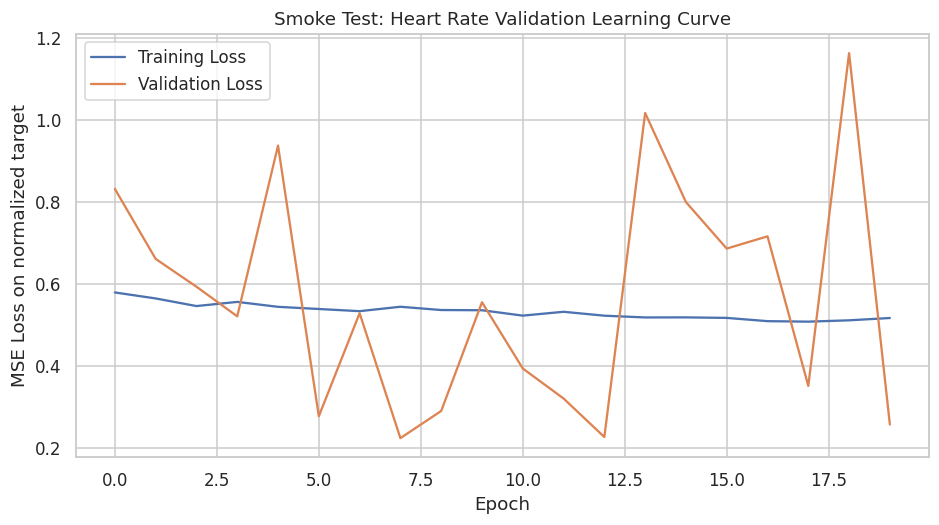

In [16]:
def plot_learning_curve(history, title):
    """Plot training and validation loss."""
    plt.figure(figsize=(10, 5))

    plt.plot(
        history["loss"],
        label="Training Loss",
    )

    if "val_loss" in history:
        plt.plot(
            history["val_loss"],
            label="Validation Loss",
        )

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss on normalized target")
    plt.legend()
    plt.show()


plot_learning_curve(
    smoke_test_output["validation_history"],
    "Smoke Test: Heart Rate Validation Learning Curve",
)

In [17]:
# Run signals in chunks if needed.
# Example:
# SIGNALS_TO_RUN = INPUT_SIGNALS[:4]
# SIGNALS_TO_RUN = INPUT_SIGNALS[4:8]
# SIGNALS_TO_RUN = INPUT_SIGNALS[8:12]
# SIGNALS_TO_RUN = INPUT_SIGNALS[12:]

SIGNALS_TO_RUN = INPUT_SIGNALS

existing_results = load_existing_results()

for signal_name in SIGNALS_TO_RUN:
    signal_index = INPUT_SIGNALS.index(signal_name)

    print("=" * 100)
    print("Signal:", signal_name)

    for split in loso_splits:
        fold = split["Fold"]

        if is_fold_already_done(existing_results, signal_name, fold):
            print(
                f"Skipping signal '{signal_name}' | fold {fold} "
                f"because it is already saved."
            )
            continue

        print(
            f"Training signal '{signal_name}' | "
            f"fold {fold} | "
            f"test subject {split['Test Subject']}"
        )

        output = run_single_signal_fold(
            signal_name=signal_name,
            signal_index=signal_index,
            split=split,
            verbose=0,
        )

        fold_result_frame = pd.DataFrame([output["result"]])

        append_dataframe_to_csv(
            fold_result_frame,
            FOLD_RESULTS_PATH,
        )

        append_dataframe_to_csv(
            output["test_predictions"],
            WINDOW_PREDICTIONS_PATH,
        )

        append_dataframe_to_csv(
            output["test_segments"],
            SEGMENT_PREDICTIONS_PATH,
        )

        print(
            "Segment RMSE:",
            round(output["result"]["Test_Segment_RMSE_W_kg"], 3),
            "| Segment MAE:",
            round(output["result"]["Test_Segment_MAE_W_kg"], 3),
            "| Segment R2:",
            round(output["result"]["Test_Segment_R2_W_kg"], 3),
            "| Best epoch:",
            output["result"]["Best Epoch"],
        )

        # Refresh existing results after saving
        existing_results = load_existing_results()

        # Clean up TensorFlow state and Python memory
        tf.keras.backend.clear_session()
        gc.collect()

print("Finished requested signal chunk.")

Signal: Waist Acceleration
Training signal 'Waist Acceleration' | fold 1 | test subject 1
Segment RMSE: 2.158 | Segment MAE: 1.809 | Segment R2: 0.228 | Best epoch: 15
Training signal 'Waist Acceleration' | fold 2 | test subject 2
Segment RMSE: 1.838 | Segment MAE: 1.494 | Segment R2: 0.665 | Best epoch: 5
Training signal 'Waist Acceleration' | fold 3 | test subject 3
Segment RMSE: 1.678 | Segment MAE: 1.348 | Segment R2: 0.714 | Best epoch: 20
Training signal 'Waist Acceleration' | fold 4 | test subject 4
Segment RMSE: 2.012 | Segment MAE: 1.755 | Segment R2: 0.573 | Best epoch: 12
Training signal 'Waist Acceleration' | fold 5 | test subject 5
Segment RMSE: 2.623 | Segment MAE: 1.967 | Segment R2: 0.314 | Best epoch: 12
Training signal 'Waist Acceleration' | fold 6 | test subject 6
Segment RMSE: 1.75 | Segment MAE: 1.49 | Segment R2: 0.674 | Best epoch: 21
Training signal 'Waist Acceleration' | fold 7 | test subject 7
Segment RMSE: 2.555 | Segment MAE: 2.007 | Segment R2: 0.515 | Best

2026-06-21 09:27:53.034850: E external/local_xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module a_inference_one_step_on_data_3379929__.4701] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


In [ ]:
single_signal_fold_results = pd.read_csv(FOLD_RESULTS_PATH)
single_signal_window_predictions = pd.read_csv(WINDOW_PREDICTIONS_PATH)
single_signal_segment_predictions = pd.read_csv(SEGMENT_PREDICTIONS_PATH)

print("Saved fold results:", single_signal_fold_results.shape)
print("Saved window predictions:", single_signal_window_predictions.shape)
print("Saved segment predictions:", single_signal_segment_predictions.shape)

display(single_signal_fold_results.head())

In [ ]:
# Save clean final copies after all chunks have completed
single_signal_fold_results.to_csv(
    OUTPUT_DIR / "single_signal_fold_results.csv",
    index=False,
)

single_signal_window_predictions.to_csv(
    OUTPUT_DIR / "single_signal_window_predictions.csv",
    index=False,
)

single_signal_segment_predictions.to_csv(
    OUTPUT_DIR / "single_signal_segment_predictions.csv",
    index=False,
)

with open(OUTPUT_DIR / "FINAL_CNN_CONFIG.json", "w") as file:
    json.dump(FINAL_CNN_CONFIG, file, indent=2)

print(f"Saved final copies to: {OUTPUT_DIR}")

In [ ]:
single_signal_ranking = (
    single_signal_fold_results
    .groupby("Signal")
    .agg(
        Mean_Segment_RMSE_W_kg=(
            "Test_Segment_RMSE_W_kg",
            "mean",
        ),
        Std_Segment_RMSE_W_kg=(
            "Test_Segment_RMSE_W_kg",
            "std",
        ),
        Mean_Segment_MAE_W_kg=(
            "Test_Segment_MAE_W_kg",
            "mean",
        ),
        Mean_Segment_R2_W_kg=(
            "Test_Segment_R2_W_kg",
            "mean",
        ),
        Mean_Segment_RMSE_kcal_min=(
            "Test_Segment_RMSE_kcal_min",
            "mean",
        ),
        Mean_Segment_MAE_kcal_min=(
            "Test_Segment_MAE_kcal_min",
            "mean",
        ),
        Mean_Best_Epoch=(
            "Best Epoch",
            "mean",
        ),
        Mean_Parameters=(
            "Number of Parameters",
            "mean",
        ),
    )
    .sort_values("Mean_Segment_RMSE_W_kg")
    .reset_index()
)

display(single_signal_ranking)

single_signal_ranking.to_csv(
    OUTPUT_DIR / "single_signal_ranking.csv",
    index=False,
)

In [ ]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=single_signal_ranking,
    y="Signal",
    x="Mean_Segment_RMSE_W_kg",
    color="steelblue",
)

plt.title("Single-Signal Ranking by Segment-Level RMSE")
plt.xlabel("Mean Segment RMSE (W/kg)")
plt.ylabel("Signal")
plt.show()

In [ ]:
plt.figure(figsize=(12, 7))

r2_ranking = single_signal_ranking.sort_values(
    "Mean_Segment_R2_W_kg",
    ascending=False,
)

sns.barplot(
    data=r2_ranking,
    y="Signal",
    x="Mean_Segment_R2_W_kg",
    color="mediumseagreen",
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
)

plt.title("Single-Signal Ranking by Segment-Level R²")
plt.xlabel("Mean Segment R²")
plt.ylabel("Signal")
plt.show()

In [ ]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=single_signal_fold_results,
    y="Signal",
    x="Test_Segment_RMSE_W_kg",
    order=single_signal_ranking["Signal"],
)

plt.title("Single-Signal RMSE Distribution Across LOSO Folds")
plt.xlabel("Segment RMSE (W/kg)")
plt.ylabel("Signal")
plt.show()

In [ ]:
best_signal = single_signal_ranking.iloc[0]
worst_signal = single_signal_ranking.iloc[-1]

print("Best signal:")
display(best_signal.to_frame().T)

print("Worst signal:")
display(worst_signal.to_frame().T)

In [ ]:
best_signal_name = best_signal["Signal"]

best_signal_segments = single_signal_segment_predictions[
    single_signal_segment_predictions["Signal"] == best_signal_name
].copy()

plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=best_signal_segments,
    x="Target_W_kg",
    y="Prediction_W_kg",
    hue="Subject",
    palette="tab10",
)

minimum_value = min(
    best_signal_segments["Target_W_kg"].min(),
    best_signal_segments["Prediction_W_kg"].min(),
)

maximum_value = max(
    best_signal_segments["Target_W_kg"].max(),
    best_signal_segments["Prediction_W_kg"].max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="black",
    linestyle="--",
    label="Perfect Prediction",
)

plt.title(f"Best Single Signal: {best_signal_name}")
plt.xlabel("Actual EE (W/kg)")
plt.ylabel("Predicted EE (W/kg)")
plt.axis("equal")
plt.legend()
plt.show()

In [ ]:
best_signal_segments["Absolute Error W/kg"] = np.abs(
    best_signal_segments["Target_W_kg"]
    - best_signal_segments["Prediction_W_kg"]
)

subject_error_summary = (
    best_signal_segments
    .groupby("Subject")
    .agg(
        Number_of_Segments=(SEGMENT_COLUMN, "size"),
        Mean_Absolute_Error_W_kg=("Absolute Error W/kg", "mean"),
        Max_Absolute_Error_W_kg=("Absolute Error W/kg", "max"),
    )
    .reset_index()
)

display(subject_error_summary)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=subject_error_summary,
    x="Subject",
    y="Mean_Absolute_Error_W_kg",
    color="orange",
)

plt.title(f"Subject-Level Error for Best Signal: {best_signal_name}")
plt.xlabel("Subject")
plt.ylabel("Mean Absolute Error (W/kg)")
plt.show()